# Exploración de datos — Predicción del resultado al entretiempo

**Proyecto · Entrega 1 — MIIA, Universidad de los Andes**

**Pregunta principal.** Al entretiempo de un partido de Copa del Mundo, ¿en cuánto mejora la
estimación del resultado final (1X2) al incorporar las métricas de dominio del primer tiempo
(xG, remates, posesión) frente a un modelo que **solo usa el marcador al descanso**?

**Pregunta específica.** ¿El "dominio sin ventaja en el marcador" es una señal *sobrevalorada*
—esos equipos ganan menos de lo que su dominio sugeriría— y por tanto una trampa para apostar en vivo?

**Datos.** StatsBomb Open Data (eventos) — Mundial 2022, Euro 2024, Euro 2020 y Copa América 2024
(198 partidos, 396 filas equipo-partido).

> Reproducibilidad: este notebook carga `data/processed/team_match_dataset.csv`.
> Si no existe, genéralo primero con `python src/build_dataset.py`.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from pathlib import Path

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.color": "#E6E8EF", "axes.axisbelow": True})
C = {"W": "#2BB48A", "D": "#9AA3BD", "L": "#E2576B", "warn": "#D99A2B", "accent": "#5B79F0"}
pctfmt = mtick.PercentFormatter(1.0)

## 1. Carga de datos

In [2]:
cands = [Path("data/processed/team_match_dataset.csv"),
         Path("../data/processed/team_match_dataset.csv")]
path = next((p for p in cands if p.exists()), None)
assert path is not None, "No se encontró el dataset. Corre primero: python src/build_dataset.py"

df = pd.read_csv(path)
print(f"Filas (equipo-partido): {len(df)} | Partidos: {df.match_id.nunique()} | Torneos: {df.torneo.nunique()}")
df.head()

Filas (equipo-partido): 396 | Partidos: 198 | Torneos: 4


,torneo,fase,match_id,equipo,rival,pos_h1,rem_h1,arco_h1,xg_h1,goles_h1,pos_diff,rem_diff,arco_diff,xg_diff,estado_ht,resultado_ft
0,Mundial 2022,Grupos,3857271,England,Iran,81.5,7,4,0.731,3,63.0,6,4,0.618,Lead,W
1,Mundial 2022,Grupos,3857271,Iran,England,18.5,1,0,0.112,0,-63.0,-6,-4,-0.618,Trail,L
2,Mundial 2022,Grupos,3857273,Wales,Iran,64.3,4,2,0.204,0,28.6,-1,0,-0.018,Level,L
3,Mundial 2022,Grupos,3857273,Iran,Wales,35.7,5,2,0.222,0,-28.6,1,0,0.018,Level,W
4,Mundial 2022,Grupos,3857296,Croatia,Belgium,47.1,6,0,0.346,0,-5.8,1,0,-0.057,Level,D


## 2. Estructura y calidad de los datos

In [3]:
print("Tipos de dato:"); print(df.dtypes)
print("\nValores faltantes (total):", int(df.isna().sum().sum()))
print("\nPartidos por torneo y fase:")
df.groupby(["torneo", "fase"]).match_id.nunique().unstack(fill_value=0)

Tipos de dato:
torneo              str
fase                str
match_id          int64
equipo              str
rival               str
pos_h1          float64
rem_h1            int64
arco_h1           int64
xg_h1           float64
goles_h1          int64
pos_diff        float64
rem_diff          int64
arco_diff         int64
xg_diff         float64
estado_ht           str
resultado_ft        str
dtype: object

Valores faltantes (total): 0

Partidos por torneo y fase:


fase,Eliminación,Grupos
torneo,,
Copa América 2024,8,24
Euro 2020,15,36
Euro 2024,15,36
Mundial 2022,16,48


In [4]:
print("Distribución del objetivo (resultado a 90'):")
display((df.resultado_ft.value_counts(normalize=True).mul(100).round(1)).rename("%").to_frame())
print("Distribución del estado al descanso:")
(df.estado_ht.value_counts(normalize=True).mul(100).round(1)).rename("%").to_frame()

Distribución del objetivo (resultado a 90'):


,%
resultado_ft,
W,33.6
L,33.6
D,32.8


Distribución del estado al descanso:


,%
estado_ht,
Level,47.0
Lead,26.5
Trail,26.5


## 3. El marcador al descanso ya es un predictor fuerte (benchmark)

Punto de partida: ¿cuánto separa el resultado el solo hecho de ir ganando, empatando o perdiendo
al descanso? Esta es la base que las métricas de dominio deben superar.

resultado_ft,Ganó%,Empató%,Perdió%
estado_ht,,,
Lead,75,19,6
Level,26,48,26
Trail,6,19,75


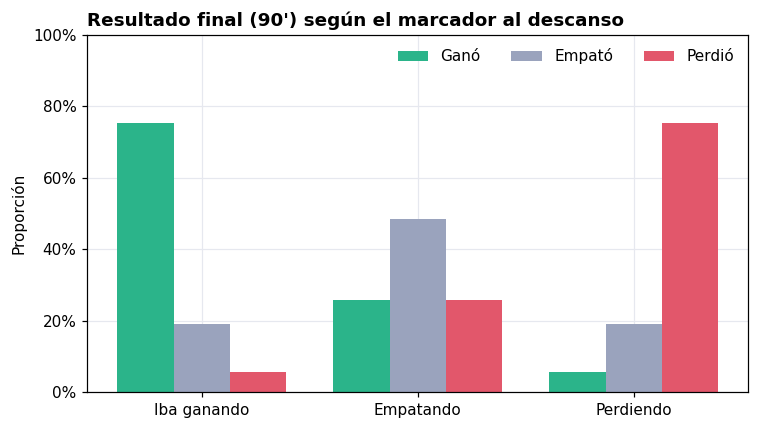

In [5]:
order = ["Lead", "Level", "Trail"]
lab = {"Lead": "Iba ganando", "Level": "Empatando", "Trail": "Perdiendo"}
ct = pd.crosstab(df.estado_ht, df.resultado_ft, normalize="index").reindex(order)[["W", "D", "L"]]
display((ct * 100).round(0).astype(int).rename(columns={"W": "Ganó%", "D": "Empató%", "L": "Perdió%"}))

fig, ax = plt.subplots(figsize=(7, 4)); x = np.arange(3); w = .26
for i, (r, nm, col) in enumerate([("W", "Ganó", C["W"]), ("D", "Empató", C["D"]), ("L", "Perdió", C["L"])]):
    ax.bar(x + (i - 1) * w, ct[r], w, label=nm, color=col)
ax.set_xticks(x); ax.set_xticklabels([lab[o] for o in order]); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(pctfmt); ax.set_ylabel("Proporción")
ax.set_title("Resultado final (90') según el marcador al descanso", fontweight="bold", loc="left")
ax.legend(frameon=False, ncol=3); plt.tight_layout(); plt.show()

**Observación.** Quien va ganando al descanso gana el partido ~75% de las veces; quien va perdiendo,
~6%. El marcador parcial es un benchmark exigente.

## 4. El dominio (xG) correlaciona con el resultado, pero de forma moderada

,mean,median,std,count
resultado_ft,,,,
D,0.000,0.000,0.472,130
L,-0.335,-0.244,0.695,133
W,0.335,0.244,0.695,133


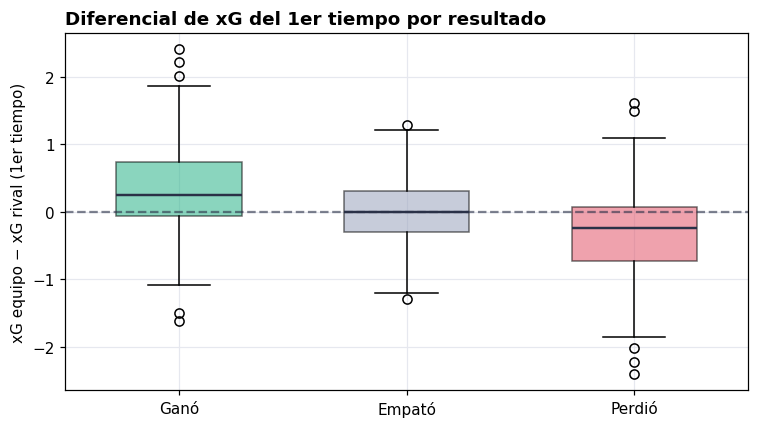

In [6]:
display(df.groupby("resultado_ft")["xg_diff"].agg(["mean", "median", "std", "count"]).round(3))

fig, ax = plt.subplots(figsize=(7, 4))
data = [df[df.resultado_ft == r]["xg_diff"] for r in ["W", "D", "L"]]
bp = ax.boxplot(data, patch_artist=True, tick_labels=["Ganó", "Empató", "Perdió"], widths=.55,
                medianprops=dict(color="#2A3147", linewidth=1.6))
for p, col in zip(bp["boxes"], [C["W"], C["D"], C["L"]]):
    p.set_facecolor(col); p.set_alpha(.55)
ax.axhline(0, ls="--", color="#2A3147", alpha=.6)
ax.set_ylabel("xG equipo − xG rival (1er tiempo)")
ax.set_title("Diferencial de xG del 1er tiempo por resultado", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

**Observación.** Ganadores +0.34 de xG_diff en promedio, perdedores −0.34, empates 0.00. Hay relación,
pero el solapamiento es amplio: el dominio por sí solo separa débilmente.

## 5. Dominio engañoso: dominar sin ir ganando rara vez termina en victoria

El caso clave de la hipótesis: equipos que dominaron el xG del primer tiempo (diferencial > +0.3)
pero **no iban ganando** al descanso.

,n,Ganó%,Empató%,Perdió%
Iba ganando,105.0,75.2,19.0,5.7
Dominó sin ir ganando,58.0,29.3,44.8,25.9
Todos los equipos,396.0,33.6,32.8,33.6


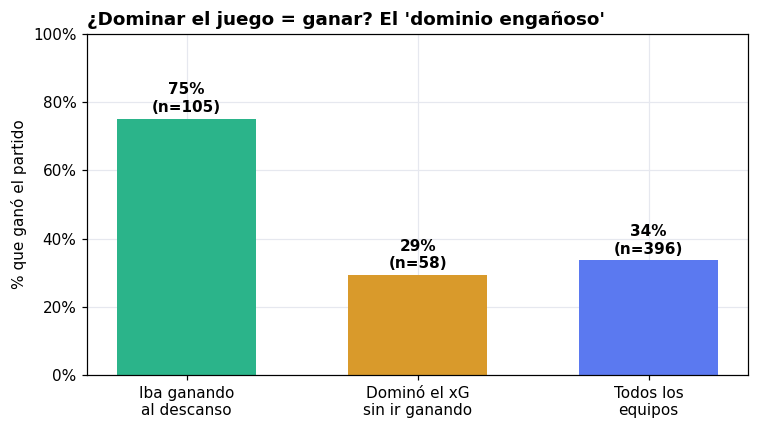

In [7]:
lead = df[df.estado_ht == "Lead"]
dom_nolead = df[(df.xg_diff > 0.3) & (df.estado_ht != "Lead")]

def wld(g):
    return pd.Series({"n": len(g),
                      "Ganó%": round(100 * (g.resultado_ft == "W").mean(), 1),
                      "Empató%": round(100 * (g.resultado_ft == "D").mean(), 1),
                      "Perdió%": round(100 * (g.resultado_ft == "L").mean(), 1)})

resumen = pd.DataFrame({"Iba ganando": wld(lead),
                        "Dominó sin ir ganando": wld(dom_nolead),
                        "Todos los equipos": wld(df)}).T
display(resumen)

grupos = [("Iba ganando\nal descanso", lead),
          ("Dominó el xG\nsin ir ganando", dom_nolead),
          ("Todos los\nequipos", df)]
wr = [(x.resultado_ft == "W").mean() for _, x in grupos]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([k for k, _ in grupos], wr, color=[C["W"], C["warn"], C["accent"]], width=.6)
for bb, ww, nn in zip(bars, wr, [len(x) for _, x in grupos]):
    ax.text(bb.get_x() + bb.get_width() / 2, ww + .02, f"{ww*100:.0f}%\n(n={nn})",
            ha="center", fontweight="bold")
ax.set_ylim(0, 1); ax.yaxis.set_major_formatter(pctfmt); ax.set_ylabel("% que ganó el partido")
ax.set_title("¿Dominar el juego = ganar? El 'dominio engañoso'", fontweight="bold", loc="left")
plt.tight_layout(); plt.show()

**Observación.** Dominar sin ir ganando lleva a victoria solo ~29% de las veces (vs. ~75% de quien
lidera) y **empata ~45%**. La señal de dominio sin gol conduce sobre todo al empate: el mercado que
favorece al equipo dominante en esos casos está pagando, a lo sumo, por un volado.

## 6. La trampa se agrava en la fase de eliminación

,Iba ganando,Dominó sin ir ganando,n (dominó s/ganar)
Grupos,75.7,32.0,50
Eliminación,74.3,12.5,8


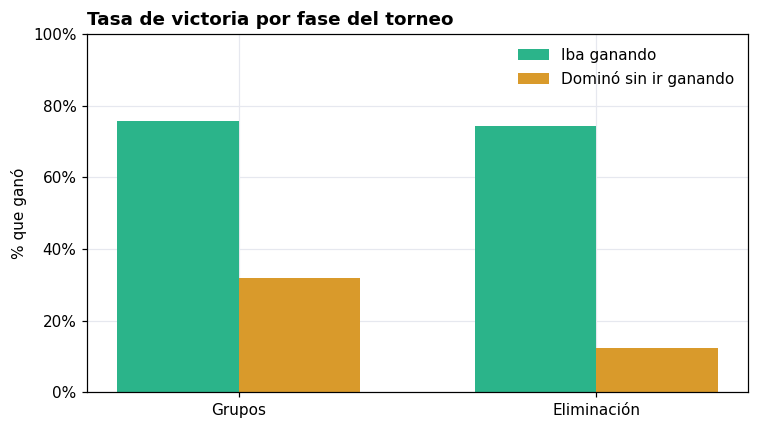

In [8]:
fases = ["Grupos", "Eliminación"]
tab = pd.DataFrame({
    "Iba ganando": [round(100 * (lead[lead.fase == f].resultado_ft == "W").mean(), 1) for f in fases],
    "Dominó sin ir ganando": [round(100 * (dom_nolead[dom_nolead.fase == f].resultado_ft == "W").mean(), 1) for f in fases],
    "n (dominó s/ganar)": [int((dom_nolead.fase == f).sum()) for f in fases],
}, index=fases)
display(tab)

fig, ax = plt.subplots(figsize=(7, 4)); x = np.arange(2); w = .34
ax.bar(x - w / 2, tab["Iba ganando"] / 100, w, label="Iba ganando", color=C["W"])
ax.bar(x + w / 2, tab["Dominó sin ir ganando"] / 100, w, label="Dominó sin ir ganando", color=C["warn"])
ax.set_xticks(x); ax.set_xticklabels(fases); ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(pctfmt); ax.set_ylabel("% que ganó")
ax.set_title("Tasa de victoria por fase del torneo", fontweight="bold", loc="left")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

**Observación.** Entre los que dominaron sin ir ganando, la tasa de victoria cae de ~32% en grupos a
~12.5% en eliminación: defender el 0-0 hacia la prórroga abarata aún más el dominio sin gol.

## 7. Exploración adicional orientada al modelado

¿Cuál de los diferenciales del primer tiempo se relaciona más con el resultado? Usamos un puntaje
numérico (ganar=3, empatar=1, perder=0) y la tasa de victoria por tramos de xG_diff.

In [9]:
df["pts"] = df.resultado_ft.map({"W": 3, "D": 1, "L": 0})
feats = ["pos_diff", "rem_diff", "arco_diff", "xg_diff"]
print("Correlación de cada diferencial del 1er tiempo con el puntaje del resultado:")
display(df[feats + ["pts"]].corr()["pts"].drop("pts").round(3).rename("corr").to_frame())

df["xg_bin"] = pd.cut(df.xg_diff, [-9, -0.5, -0.1, 0.1, 0.5, 9],
                      labels=["≤ −0.5", "−0.5 a −0.1", "≈ 0", "0.1 a 0.5", "> 0.5"])
wr_bin = df.groupby("xg_bin", observed=True).agg(
    n=("resultado_ft", "size"),
    gana_pct=("resultado_ft", lambda s: round(100 * (s == "W").mean(), 1)))
display(wr_bin)

Correlación de cada diferencial del 1er tiempo con el puntaje del resultado:


,corr
pos_diff,0.296
rem_diff,0.366
arco_diff,0.411
xg_diff,0.394


,n,gana_pct
xg_bin,,
≤ −0.5,75,13.3
−0.5 a −0.1,92,22.8
≈ 0,63,39.7
0.1 a 0.5,91,30.8
> 0.5,75,65.3


**Observación.** Entre los diferenciales, `xg_diff` es el más asociado al resultado (aunque la
correlación es modesta), por encima de remates o posesión: la *calidad* de las ocasiones pesa más que
el volumen. La tasa de victoria crece de forma casi monótona con `xg_diff`, pero incluso dominando
fuerte (> +0.5) queda lejos del efecto de ir ganando en el marcador.

## 8. Conclusiones e implicaciones para el modelado

- El **marcador al descanso** es un predictor fuerte (75% vs 6%): es el benchmark a superar.
- El **dominio (xG)** aporta señal pero **moderada**; por sí solo separa poco.
- **Dominio engañoso confirmado:** dominar sin ir ganando lleva a victoria ~29% (mayormente empate ~45%),
  y peor aún en eliminación (~12.5%). La hipótesis se sostiene.
- Entre las métricas de dominio, **xG_diff** es la más informativa.

**Para la Entrega 2:** el modelo debe **combinar marcador + dominio**; el valor agregado de las _h1
estará sobre todo en re-calibrar los casos de marcador parejo/adverso. Línea base: regresión logística
multinomial; comparación con Random Forest / XGBoost; evaluación con **log-loss / Brier** (calidad de
probabilidad) bajo validación cruzada estratificada, controlando la dependencia entre las dos filas de
cada partido.